<a href="https://colab.research.google.com/github/NafarFatima/Web_scraper/blob/main/Yolo_datset_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

src = "/content/drive/MyDrive/Yolo-datset"
dst = "/content/Yolo-datset"

shutil.copytree(src, dst, dirs_exist_ok=True)

print("Dataset copied locally ✔")

Dataset copied locally ✔


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [ ]:
fixed_yaml = """
train: /content/Yolo-datset/train/images
val: /content/Yolo-datset/train/images

nc: 4
names: ['glass', 'metal', 'paper', 'plastic']
"""

with open("/content/Yolo-datset/data.yaml", "w") as f:
    f.write(fixed_yaml)

print("Fixed YAML saved ✔")

Fixed YAML saved ✔


In [ ]:
with open("/content/Yolo-datset/data.yaml", "r") as f:
    print(f.read())


train: /content/Yolo-datset/train/images
val: /content/Yolo-datset/train/images

nc: 4
names: ['glass', 'metal', 'paper', 'plastic']



In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/Yolo-datset/data.yaml",

    epochs=20,          # much faster
    imgsz=416,          # smaller image size
    batch=8,            # faster CPU training

    device="cpu",
    workers=1,
    cache=False,

    optimizer="AdamW",
    lr0=0.001,

    # imbalance handling
    augment=True,
    mosaic=0.3,
    mixup=0.1,
    copy_paste=0.2,

    patience=10
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Yolo-datset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea3c248f5c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
from google.colab import files
files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 322.0±231.4 MB/s, size: 18.5 KB)
val: Scanning /content/Yolo-datset/train/labels.cache... 1484 images, 441 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1484/1484 207.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 1129. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 93/93 2.0s/it 3:06
                   all       1484       1129      0.893       0.71      0.813      0.716
                 glass        288        292      0.926      0.873       0.96      0.856
                 metal        301  

In [ ]:
print(metrics.box.f1)

[     0.8988     0.81203     0.49284     0.88711]


In [ ]:
f1 = 2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr)

print("F1 Score:", f1)

F1 Score: 0.7910946806977049


In [ ]:
!ls /content/runs/detect/train

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1860.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch1861.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch1862.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg     weights
labels.jpg			 train_batch2.jpg


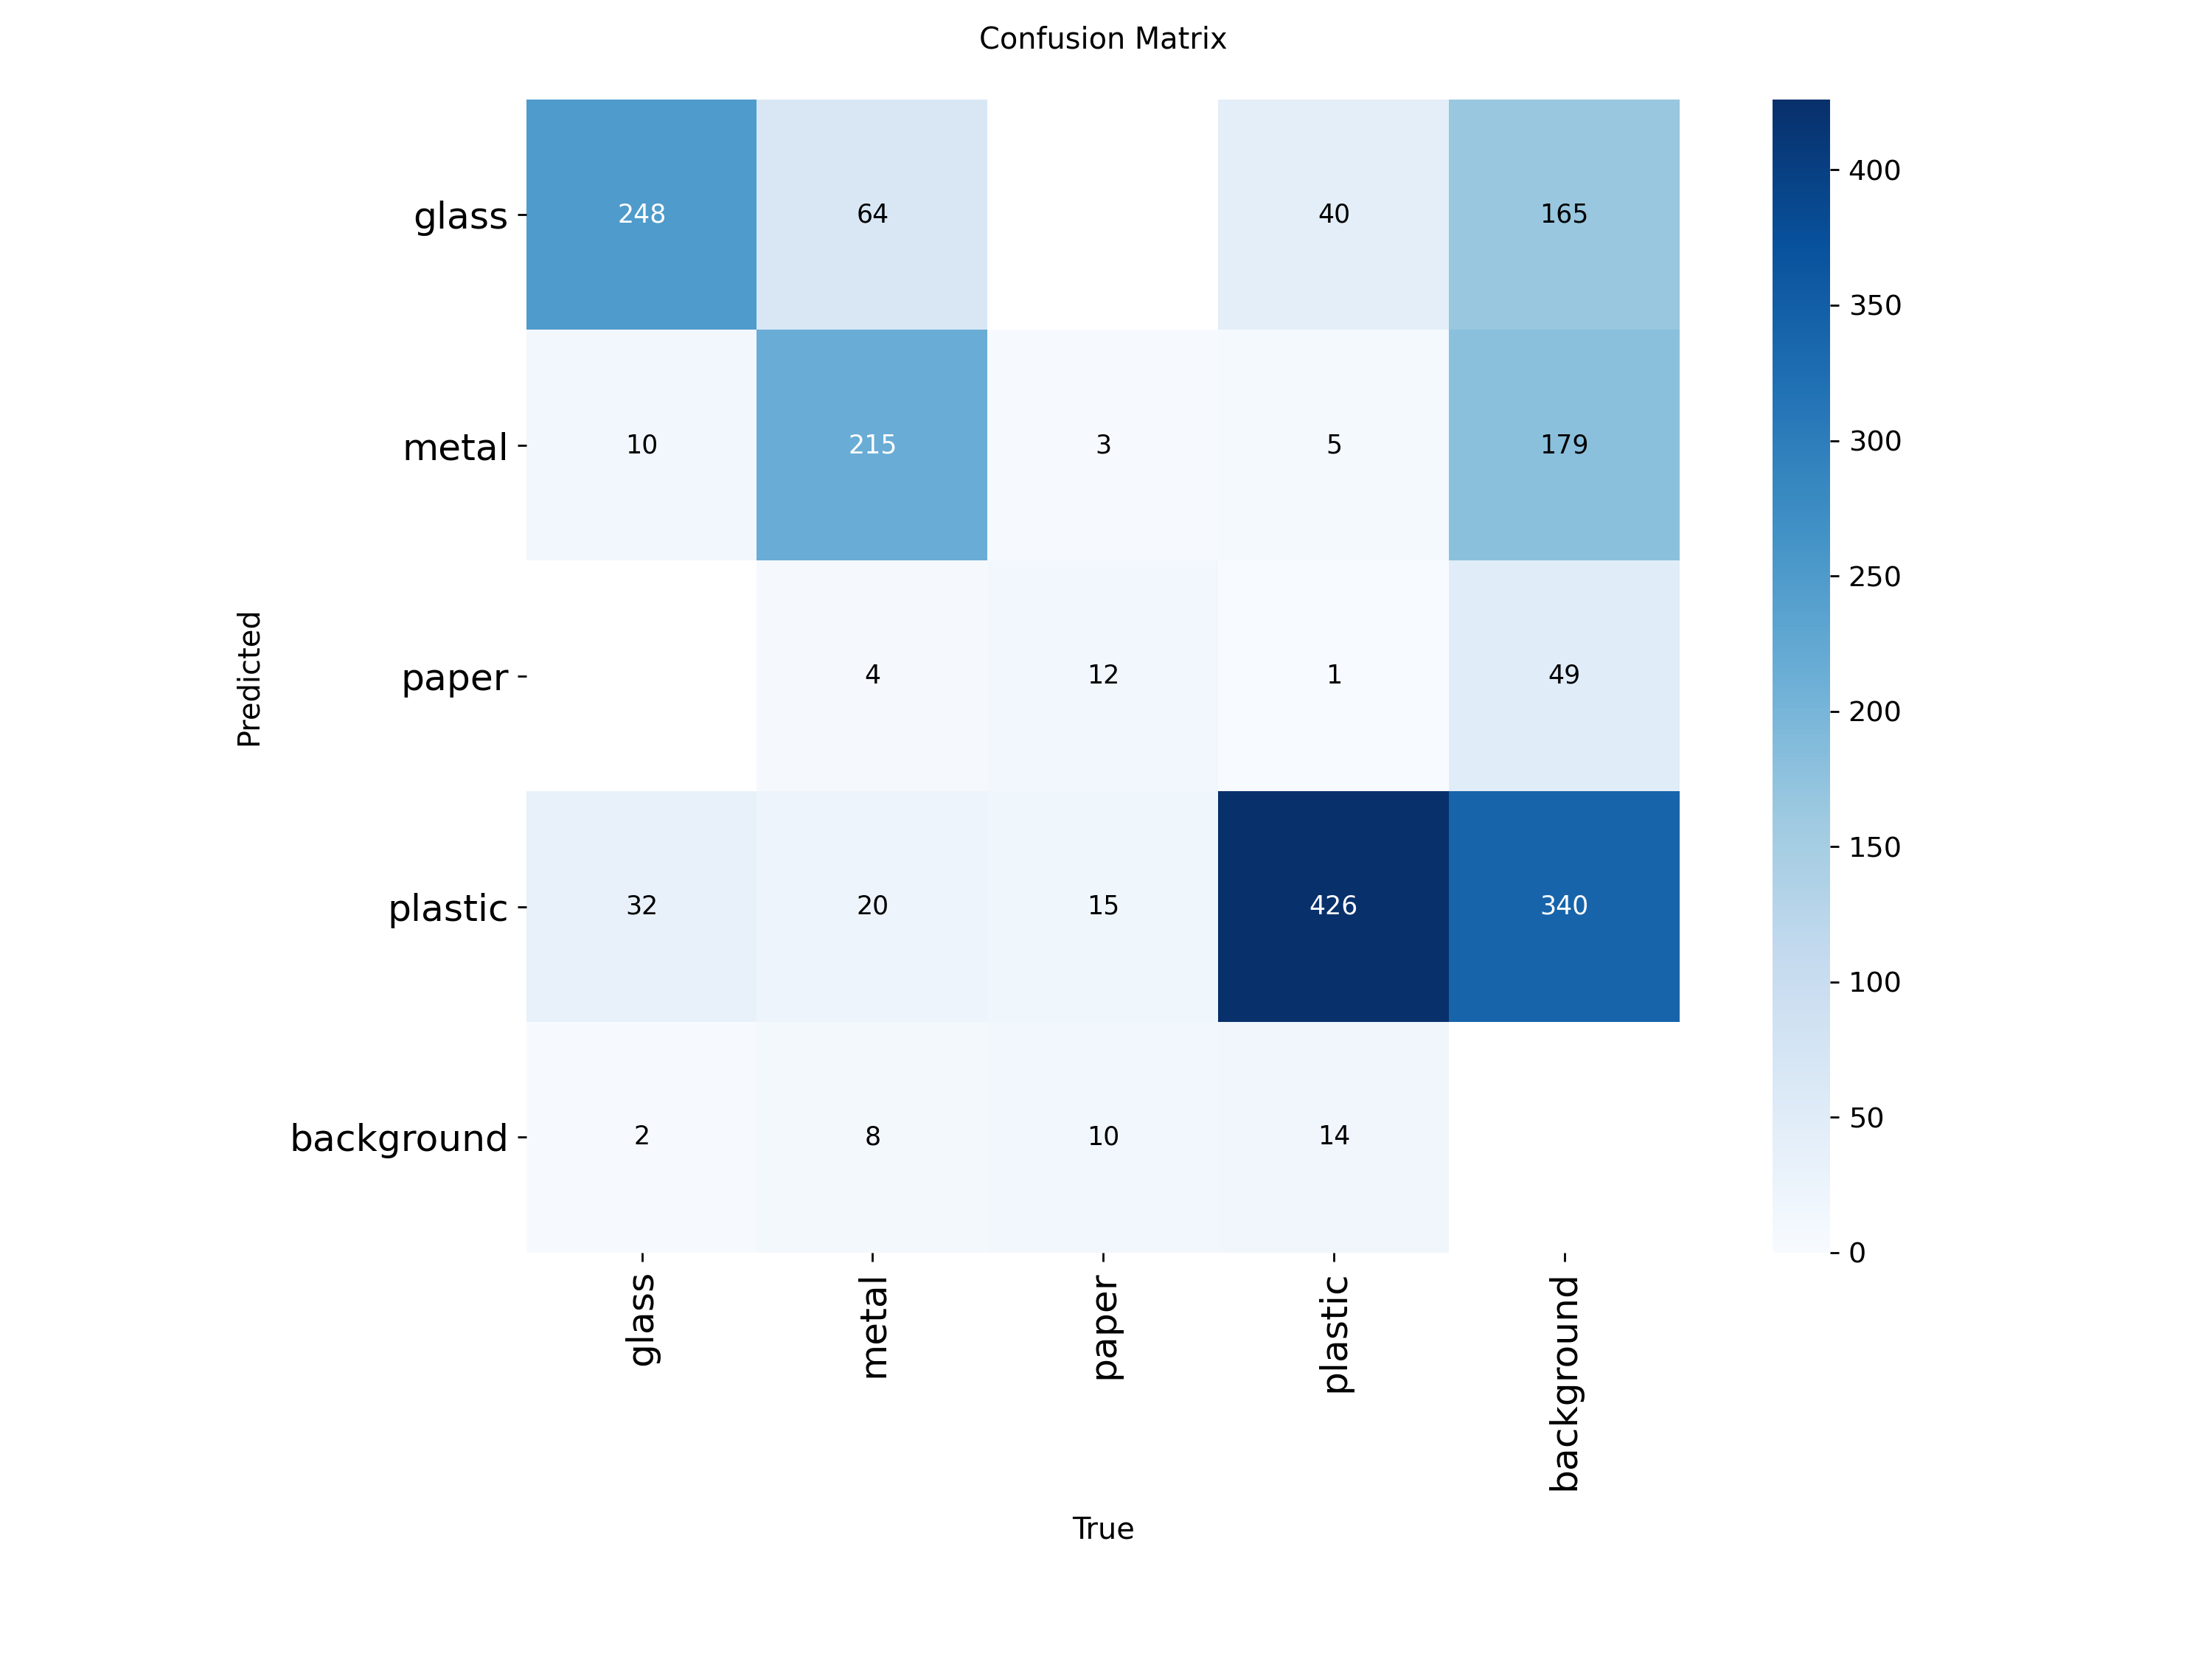

In [ ]:
from IPython.display import Image, display

display(Image("/content/runs/detect/train/confusion_matrix.png"))


# Confusion matrix heatmap

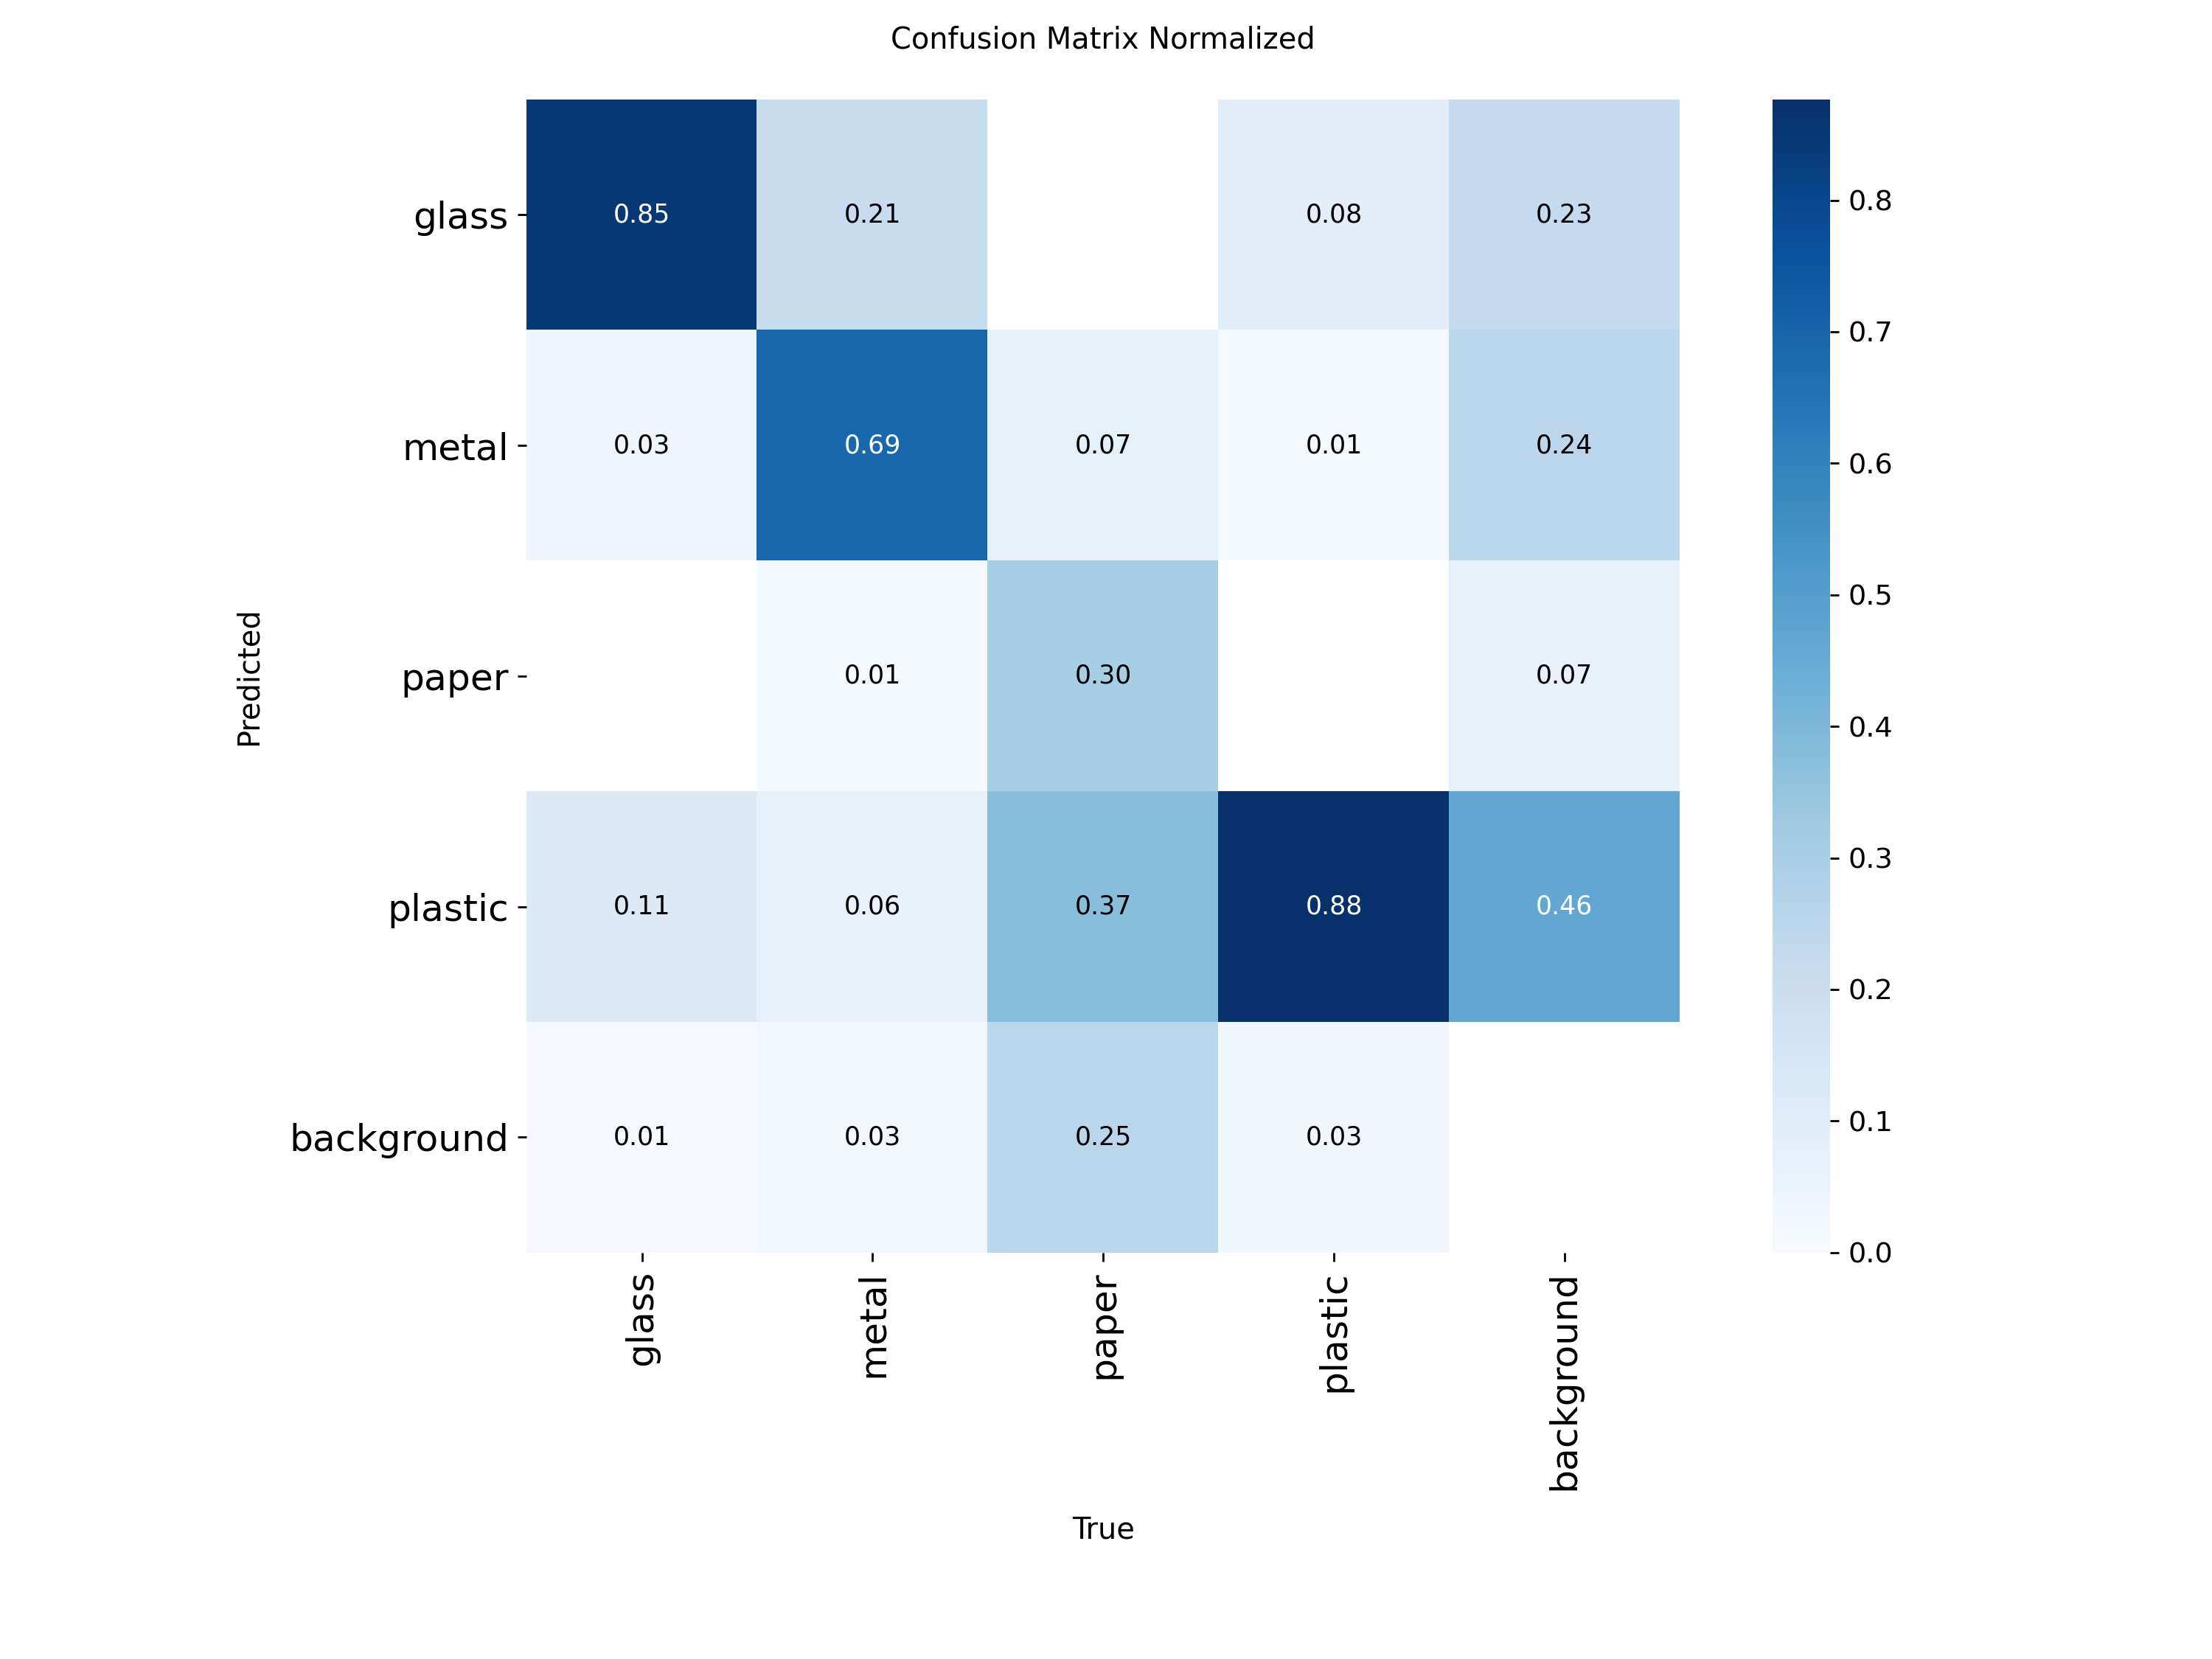

In [ ]:
display(Image("/content/runs/detect/train/confusion_matrix_normalized.png"))

In [ ]:
!find /content -name best.pt

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving best.pt to best.pt


In [ ]:
!unzip best.zip

unzip:  cannot find or open best.zip, best.zip.zip or best.zip.ZIP.


In [ ]:
!ls /content

best.pt  sample_data


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

In [ ]:
model.export(format="onnx")

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 8, 3549) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 458ms
Prepared 4 packages in 2.02s
Installed 4 packages in 291ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 3.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: e

'/content/best.onnx'

In [ ]:
from google.colab import files
files.download("/content/best.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>